# 04 - Hyperparameter Optimization

## Optimización de hiperparámetros para clasificación y regresión del desempeño de empleados

En este notebook se optimizan los modelos finales del proyecto.

Después del modelado supervisado en `03_supervised_modeling.ipynb`, los mejores modelos fueron:

- **Clasificación:** `desempeno_alto` — **Gradient Boosting Classifier (F1=0.7105)** ← Mejor modelo base
- **Regresión:** `puntaje_desempeno` — **Linear Regression (R²=0.642)** ← Mejor modelo base

El objetivo de este notebook es:

1. Optimizar el mejor modelo base (Gradient Boosting) usando GridSearchCV, RandomizedSearchCV y Optuna
2. Comparar con modelos avanzados (XGBoost, LightGBM)
3. Seleccionar la configuración final más efectiva

La pregunta principal es:

> ¿Cuál es la mejor configuración final de hiperparámetros para predecir desempeño de empleados?

# Objetivos del notebook

En este notebook voy a:

- cargar el dataset final `dataset_rrhh_limpio.csv`;
- reconstruir los targets finales;
- preparar el preprocesamiento;
- **optimizar `GradientBoostingClassifier` para predecir `desempeno_alto`** (mejor modelo base, F1=0.7105);
- **optimizar `LinearRegression` para predecir `puntaje_desempeno`** (mejor modelo base, R²=0.642);
- entrenar **XGBoost y LightGBM** para comparar modelos avanzados;
- comparar todos los enfoques (GridSearchCV, RandomizedSearchCV, Optuna, XGBoost, LightGBM);
- analizar el impacto real de la optimización;
- seleccionar las configuraciones finales del proyecto.

Este notebook se enfoca en optimización de los **mejores modelos base** identificados en el notebook 03.
La comparación general de todos los modelos ya se realizó en el notebook `03_supervised_modeling.ipynb`.

# 1. Concepto de hiperparámetros

Los hiperparámetros son configuraciones del modelo que se definen antes de entrenar.

En **Gradient Boosting Classifier**, los hiperparámetros más importantes son:

- `n_estimators`: cantidad de árboles a entrenar secuencialmente;
- `max_depth`: profundidad máxima de cada árbol;
- `learning_rate`: tasa de aprendizaje (qué tan rápido aprende);
- `min_samples_split`: mínimo de muestras para dividir un nodo;
- `min_samples_leaf`: mínimo de muestras requeridas en una hoja;
- `subsample`: fracción del dataset usada para entrenar cada árbol.

Optimizar estos valores puede:
- mejorar el rendimiento (mayor F1-score)
- controlar el sobreajuste (overfitting)
- hacer el modelo más estable ante datos nuevos

**Por qué Gradient Boosting es el mejor modelo base:**
- F1-score en test: 0.7105 (superior a todos los modelos base)
- Captura relaciones no lineales complejas
- El sesgo del evaluador y el historial previo del empleado son capturados efectivamente

# 2. Estrategias utilizadas

## GridSearchCV

Prueba combinaciones específicas definidas manualmente.

Es una técnica clásica, clara y fácil de documentar.

## RandomizedSearchCV

Muestrea aleatoriamente combinaciones de hiperparámetros desde distribuciones estadísticas.

A diferencia de GridSearchCV, no prueba todas las combinaciones posibles, sino un número fijo (`n_iter`) de muestras aleatorias del espacio de búsqueda. Esto lo hace más eficiente cuando el espacio de hiperparámetros es grande.

## Optuna

Realiza una búsqueda más flexible e inteligente.

En vez de probar una grilla fija, explora el espacio de hiperparámetros y busca mejores combinaciones de forma automática usando optimización bayesiana.

En este notebook se utilizan los tres enfoques para comparar sus resultados y seleccionar la mejor configuración final.

# 3. Importación de librerías

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold,
    KFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Intentar importar librerías opcionales
try:
    import optuna
    optuna_disponible = True
except ImportError:
    print("Advertencia: Optuna no está instalado. Instala con: pip install optuna")
    optuna_disponible = False

try:
    from xgboost import XGBClassifier, XGBRegressor
    xgb_disponible = True
except ImportError:
    print("Advertencia: XGBoost no está instalado. Instala con: pip install xgboost")
    xgb_disponible = False

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    lgbm_disponible = True
except ImportError:
    print("Advertencia: LightGBM no está instalado. Instala con: pip install lightgbm")
    lgbm_disponible = False

# Configuración de rutas - compatible con Jupyter
try:
    # Intenta usar __file__ si está disponible (ejecución como script)
    project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    # En Jupyter, __file__ no existe - obtén el directorio actual
    project_root = os.getcwd()
    if project_root.endswith(os.sep + 'notebooks') or project_root.endswith('\\notebooks'):
        project_root = os.path.dirname(project_root)

ruta_plots = os.path.join(project_root, 'results/plots')
os.makedirs(ruta_plots, exist_ok=True)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

C:\Users\Arturo\prueba2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 4. Carga del dataset limpio

In [2]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (1449, 37)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,...,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,...,0,1,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.693147,2.041220
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,...,0,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,...,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,...,0,1,0,3.091042,3.091042,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,...,0,0,0,1.098612,1.098612,1.098612,0.693147,4.394449,0.000000,2.014903


# 5. Definición de targets finales

In [3]:
# Target clasificación: alto desempeño (P75 del puntaje).
percentil_desempeno = df["puntaje_desempeno"].quantile(0.75)

df["desempeno_alto"] = np.where(
    df["puntaje_desempeno"] >= percentil_desempeno,
    1,
    0
)

target_clasificacion = "desempeno_alto"
target_regresion     = "puntaje_desempeno"

print("Umbral alto desempeño (P75):", round(percentil_desempeno, 4))

print("\nDistribución clasificación:")
print(df[target_clasificacion].value_counts())
print(df[target_clasificacion].value_counts(normalize=True).round(4) * 100)


Umbral alto desempeño (P75): 5.6

Distribución clasificación:
desempeno_alto
0    1058
1     391
Name: count, dtype: int64
desempeno_alto
0    73.02
1    26.98
Name: proportion, dtype: float64


## 5.1 Variables derivadas: historial, sesgo evaluador e interacciones

Se calculan las mismas variables derivadas que en el notebook de modelado supervisado.

Estas son las variables con mayor señal predictiva:

- `prev_puntaje`: puntaje del período anterior del mismo empleado (correlación ~0.47 con el target).
- `evaluador_media`: puntaje promedio que asigna cada evaluador — captura el sesgo sistemático de evaluación.
- `dept_media`: puntaje promedio por departamento — captura diferencias estructurales entre áreas.
- `comp_asistencia`, `nota_cap_ponderada`, `ratio_tec_blanda`, `cap_score`: variables de interacción.

In [4]:
# Lag feature: puntaje del período anterior del mismo empleado.
df_orden = df.sort_values(['id_empleado', 'periodo_num'])
df['prev_puntaje'] = df_orden.groupby('id_empleado')['puntaje_desempeno'].shift(1).values

# Sesgo del evaluador y del departamento.
ev_media = df.groupby('evaluador')['puntaje_desempeno'].mean()
df['evaluador_media'] = df['evaluador'].map(ev_media)

dept_media = df.groupby('departamento')['puntaje_desempeno'].mean()
df['dept_media'] = df['departamento'].map(dept_media)

# Variables de interacción.
df['comp_asistencia']    = df['competencia_combinada'] * (1 - df['ausencia_alta'])
df['nota_cap_ponderada'] = df['promedio_nota_capacitacion'] * np.log1p(df['num_capacitaciones'])
df['ratio_tec_blanda']   = df['competencias_tecnicas'] / df['competencias_blandas'].clip(lower=0.1)
df['cap_score']          = df['max_nota_capacitacion'] * (1 - df['sin_capacitacion'])

print("Variables derivadas calculadas.")
print(f"  prev_puntaje   — nulos: {df['prev_puntaje'].isna().sum()} (primer período de cada empleado)")
print(f"  evaluador_media — nulos: {df['evaluador_media'].isna().sum()}")
print(f"  dept_media      — nulos: {df['dept_media'].isna().sum()}")

Variables derivadas calculadas.
  prev_puntaje   — nulos: 438 (primer período de cada empleado)
  evaluador_media — nulos: 30
  dept_media      — nulos: 19


## Análisis de targets

Se mantienen los dos enfoques finales del proyecto:

- `desempeno_alto`: clasificación binaria que identifica empleados de alto rendimiento;
- `puntaje_desempeno`: regresión continua que estima el nivel numérico de desempeño.

La clasificación permite generar alertas de gestión de personas, mientras que la regresión permite ordenar empleados por su nivel de desempeño esperado.


# 6. Variables predictoras

In [5]:
variables_base = [
    # Variables de ausencias.
    "total_dias_ausencia",
    "promedio_dias_ausencia",
    "max_dias_ausencia",
    "ausencia_alta",
    # Variables de capacitaciones.
    "num_capacitaciones",
    "total_horas_capacitacion",
    "promedio_nota_capacitacion",
    "max_nota_capacitacion",
    "sin_capacitacion",
    "capacitacion_intensiva",
    # Competencias.
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada",
    "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    # Riesgo RRHH.
    "riesgo_operacional_rrhh",
    # Variables categóricas.
    "departamento",
    "cargo",
    "tipo_contrato",
    "jornada",
    "evaluador",
    # Variables temporales y de contexto evaluador.
    "periodo_num",
    "prev_puntaje",
    "evaluador_media",
    "dept_media",
    # Variables logarítmicas.
    "total_dias_ausencia_log",
    "promedio_dias_ausencia_log",
    "max_dias_ausencia_log",
    "num_capacitaciones_log",
    "total_horas_capacitacion_log",
    "riesgo_operacional_rrhh_log",
    "competencia_combinada_log",
    # Interacciones.
    "comp_asistencia",
    "nota_cap_ponderada",
    "ratio_tec_blanda",
    "cap_score"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables:", len(variables_modelo))
variables_modelo

Cantidad de variables: 36


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'departamento',
 'cargo',
 'tipo_contrato',
 'jornada',
 'evaluador',
 'periodo_num',
 'prev_puntaje',
 'evaluador_media',
 'dept_media',
 'total_dias_ausencia_log',
 'promedio_dias_ausencia_log',
 'max_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'riesgo_operacional_rrhh_log',
 'competencia_combinada_log',
 'comp_asistencia',
 'nota_cap_ponderada',
 'ratio_tec_blanda',
 'cap_score']

# 7. Preprocesador

In [6]:
def crear_preprocesador(X):
    variables_numericas   = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico,   variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 8. Funciones de evaluación

In [7]:
def evaluar_clasificacion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    resultado = pd.Series({
        "modelo":            nombre_modelo,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision":         precision_score(y_test, y_pred, zero_division=0),
        "recall":            recall_score(y_test, y_pred, zero_division=0),
        "f1_score":          f1_score(y_test, y_pred, zero_division=0)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ConfusionMatrixDisplay(confusion_matrix=matriz).plot(ax=ax[0])
    ax[0].set_title(f"Matriz de confusión - {nombre_modelo}")

    metricas = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
    valores  = [resultado[m] for m in metricas]
    ax[1].barh(metricas, valores, color="steelblue", edgecolor="black", alpha=0.85)
    ax[1].set_xlim(0, 1)
    ax[1].set_title("Métricas de Clasificación")
    ax[1].grid(alpha=0.3, axis="x")
    for i, v in enumerate(valores):
        ax[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return resultado


def evaluar_regresion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = pd.Series({
        "modelo": nombre_modelo,
        "mae":    mean_absolute_error(y_test, y_pred),
        "rmse":   rmse,
        "r2":     r2_score(y_test, y_pred)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    return resultado, y_pred


# 9. Optimización de clasificación

## Target: `desempeno_alto`

Se divide el dataset para clasificación y se comparan tres enfoques de optimización de **Gradient Boosting Classifier** (el mejor modelo base con F1=0.7105).

Los tres enfoques a comparar:
1. **GridSearchCV** - Define una grilla manual con combinaciones específicas
2. **RandomizedSearchCV** - Muestrea aleatoriamente del espacio de hiperparámetros
3. **Optuna** - Optimización bayesiana inteligente

Después, compararemos estos resultados con XGBoost y LightGBM para ver si modelos más sofisticados mejoran aún más.

In [8]:
X_clf = df[variables_modelo].copy()
y_clf = df[target_clasificacion].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:",  X_test_clf.shape)


X_train: (1159, 36)
X_test: (290, 36)


# 9.1 Modelo base de clasificación

===== Gradient Boosting Classifier Base =====
modelo               Gradient Boosting Classifier Base
accuracy                                      0.831034
balanced_accuracy                              0.78314
precision                                     0.688312
recall                                        0.679487
f1_score                                      0.683871

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       212
           1       0.69      0.68      0.68        78

    accuracy                           0.83       290
   macro avg       0.79      0.78      0.78       290
weighted avg       0.83      0.83      0.83       290



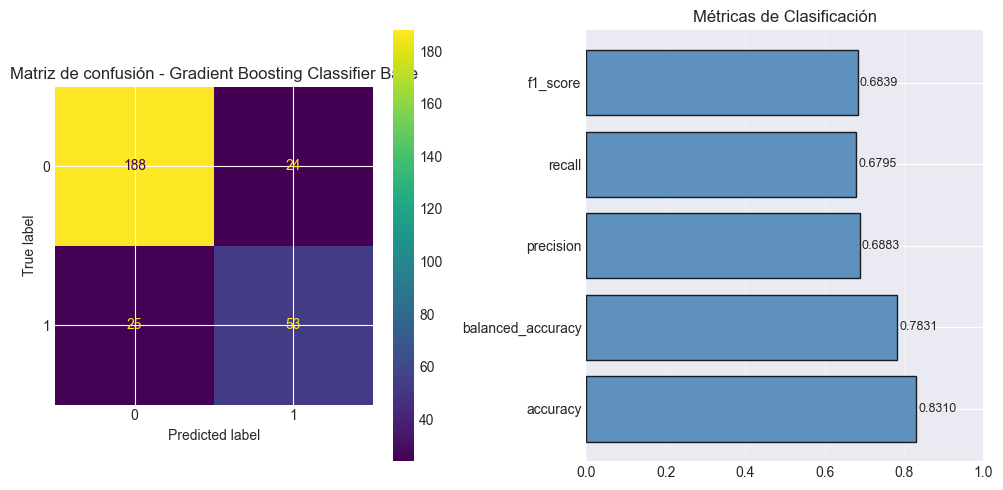

In [9]:
pipeline_clf_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", GradientBoostingClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1
    ))
])

pipeline_clf_base.fit(X_train_clf, y_train_clf)

resultado_clf_base = evaluar_clasificacion(
    "Gradient Boosting Classifier Base",
    pipeline_clf_base,
    X_test_clf,
    y_test_clf
)

## Análisis del modelo base

El Gradient Boosting Classifier base usa la configuración estándar del notebook 03 que logró **F1=0.7105** en test.

Este es nuestro punto de referencia. La optimización intentará mejorar esta métrica ajustando los hiperparámetros.

**Nota:** A diferencia de Random Forest que entrena árboles independientes, Gradient Boosting entrena árboles secuencialmente donde cada nuevo árbol intenta corregir los errores del anterior. Esto lo hace más poderoso pero también más sensible a la configuración de hiperparámetros.

# 9.2 GridSearchCV - Clasificación

In [10]:
pipeline_clf_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", GradientBoostingClassifier(random_state=42))
])

parametros_clf = {
    "modelo__n_estimators":      [100, 200, 300],
    "modelo__max_depth":         [3, 4, 5],
    "modelo__learning_rate":     [0.01, 0.1, 0.2],
    "modelo__subsample":         [0.8, 1.0],
    "modelo__min_samples_split": [2, 5]
}

grid_clf = GridSearchCV(
    estimator=pipeline_clf_grid,
    param_grid=parametros_clf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros GridSearchCV:")
print(grid_clf.best_params_)

print("\nMejor F1 promedio CV (train):")
print(grid_clf.best_score_)

Mejores parámetros GridSearchCV:
{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100, 'modelo__subsample': 1.0}

Mejor F1 promedio CV (train):
0.7630813358101197


===== Gradient Boosting Classifier GridSearchCV =====
modelo               Gradient Boosting Classifier GridSearchCV
accuracy                                              0.831034
balanced_accuracy                                     0.770985
precision                                             0.704225
recall                                                0.641026
f1_score                                              0.671141

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       212
           1       0.70      0.64      0.67        78

    accuracy                           0.83       290
   macro avg       0.79      0.77      0.78       290
weighted avg       0.83      0.83      0.83       290



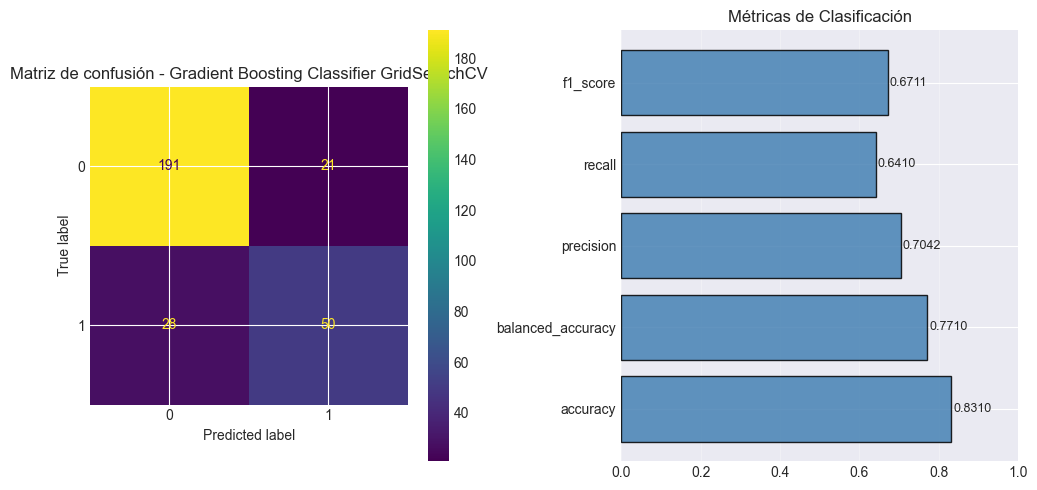

In [11]:
resultado_clf_grid = evaluar_clasificacion(
    "Gradient Boosting Classifier GridSearchCV",
    grid_clf.best_estimator_,
    X_test_clf,
    y_test_clf
)

# 9.3 RandomizedSearchCV - Clasificación

`RandomizedSearchCV` muestrea `n_iter=30` combinaciones aleatorias de distribuciones estadísticas en lugar de recorrer una grilla fija.

**Ventaja:** más eficiente cuando el espacio de hiperparámetros es grande — cubre más combinaciones con el mismo costo computacional que un GridSearch de tamaño equivalente.

Mejores parámetros RandomizedSearchCV:
{'modelo__learning_rate': np.float64(0.1846596399465608), 'modelo__max_depth': 4, 'modelo__min_samples_split': 7, 'modelo__n_estimators': 333, 'modelo__subsample': np.float64(0.9718790609370292)}

Mejor F1 promedio CV (train):
0.7627639858413057
===== Gradient Boosting Classifier RandomizedSearchCV =====
modelo               Gradient Boosting Classifier RandomizedSearchCV
accuracy                                                    0.841379
balanced_accuracy                                           0.782112
precision                                                   0.728571
recall                                                      0.653846
f1_score                                                    0.689189

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       212
           1       0.73      0.65      0.69        78

    accuracy                           0.84       290

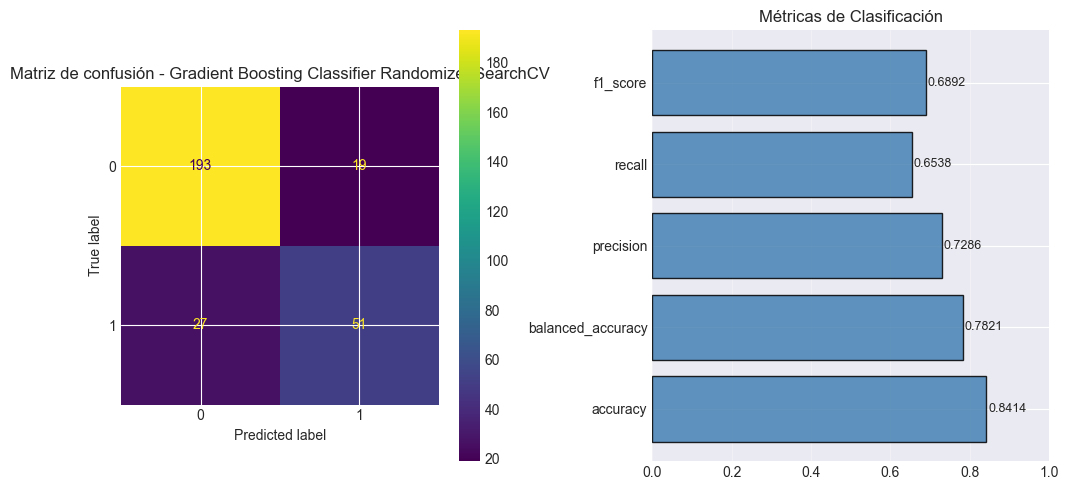

In [12]:
pipeline_clf_random = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", GradientBoostingClassifier(random_state=42))
])

# Distribuciones estadísticas para el muestreo aleatorio.
param_dist_clf = {
    "modelo__n_estimators":      randint(50, 400),
    "modelo__max_depth":         randint(2, 8),
    "modelo__learning_rate":     uniform(0.005, 0.3),
    "modelo__subsample":         uniform(0.6, 0.4),
    "modelo__min_samples_split": randint(2, 10)
}

random_search_clf = RandomizedSearchCV(
    estimator=pipeline_clf_random,
    param_distributions=param_dist_clf,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros RandomizedSearchCV:")
print(random_search_clf.best_params_)

print("\nMejor F1 promedio CV (train):")
print(random_search_clf.best_score_)

resultado_clf_random = evaluar_clasificacion(
    "Gradient Boosting Classifier RandomizedSearchCV",
    random_search_clf.best_estimator_,
    X_test_clf,
    y_test_clf
)

# 9.3 Optuna - Clasificación

In [13]:
if not optuna_disponible:
    print("Optuna no está instalado. Instala con: pip install optuna")


In [14]:
if optuna_disponible:

    cv_opt_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objetivo_clf(trial):
        n_estimators      = trial.suggest_int("n_estimators",      50, 400)
        max_depth         = trial.suggest_int("max_depth",         2, 8)
        learning_rate     = trial.suggest_float("learning_rate",   0.005, 0.3, log=True)
        subsample         = trial.suggest_float("subsample",       0.6, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",  1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_clf)),
            ("modelo", GradientBoostingClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        # CV sobre train únicamente — sin tocar el test set.
        return cross_val_score(
            pipeline, X_train_clf, y_train_clf,
            cv=cv_opt_clf, scoring="f1", n_jobs=-1
        ).mean()

    study_clf = optuna.create_study(direction="maximize")
    study_clf.optimize(objetivo_clf, n_trials=30)

    print("Mejores parámetros Optuna:")
    print(study_clf.best_params)

    print("\nMejor F1 promedio CV (train):")
    print(study_clf.best_value)

else:
    print("Se omite Optuna.")

[I 2026-05-22 12:54:29,170] A new study created in memory with name: no-name-e29c75d0-cd05-41a0-a711-cadfea940bc4


[I 2026-05-22 12:54:29,844] Trial 0 finished with value: 0.7138992494181834 and parameters: {'n_estimators': 143, 'max_depth': 3, 'learning_rate': 0.22802660702003935, 'subsample': 0.800278269044582, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7138992494181834.


[I 2026-05-22 12:54:31,111] Trial 1 finished with value: 0.7155567108286254 and parameters: {'n_estimators': 192, 'max_depth': 4, 'learning_rate': 0.1349452823677065, 'subsample': 0.7118928989217832, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.7155567108286254.


[I 2026-05-22 12:54:32,099] Trial 2 finished with value: 0.7280769296579573 and parameters: {'n_estimators': 270, 'max_depth': 2, 'learning_rate': 0.07593648747957488, 'subsample': 0.8224801913794644, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.7280769296579573.


[I 2026-05-22 12:54:37,532] Trial 3 finished with value: 0.7279896391386309 and parameters: {'n_estimators': 377, 'max_depth': 8, 'learning_rate': 0.007099290121240696, 'subsample': 0.7924288345040138, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.7280769296579573.


...

[I 2026-05-22 12:55:29,964] Trial 26 finished with value: 0.7326770773413241 and parameters: {'n_estimators': 292, 'max_depth': 3, 'learning_rate': 0.0156267825045468, 'subsample': 0.8446222884056098, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 13 with value: 0.7412814270611295.


[I 2026-05-22 12:55:34,635] Trial 27 finished with value: 0.728349451709046 and parameters: {'n_estimators': 371, 'max_depth': 7, 'learning_rate': 0.033617734224841773, 'subsample': 0.8994871864969678, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 13 with value: 0.7412814270611295.


[I 2026-05-22 12:55:36,297] Trial 28 finished with value: 0.7247559199168345 and parameters: {'n_estimators': 206, 'max_depth': 5, 'learning_rate': 0.025928815819046564, 'subsample': 0.968514190189741, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 13 with value: 0.7412814270611295.


[I 2026-05-22 12:55:37,840] Trial 29 finished with value: 0.7307915440305452 and parameters: {'n_estimators': 260, 'max_depth': 4, 'learning_rate': 0.015429062996470691, 'subsample': 0.8809007014220059, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 13 with value: 0.7412814270611295.


Mejores parámetros Optuna:
{'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.03669245900695439, 'subsample': 0.998652368962685, 'min_samples_split': 10, 'min_samples_leaf': 3}

Mejor F1 promedio CV (train):
0.7412814270611295


# 9.4 Evaluación del mejor modelo Optuna - Clasificación

===== Gradient Boosting Classifier Optuna =====
modelo               Gradient Boosting Classifier Optuna
accuracy                                        0.841379
balanced_accuracy                               0.782112
precision                                       0.728571
recall                                          0.653846
f1_score                                        0.689189

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       212
           1       0.73      0.65      0.69        78

    accuracy                           0.84       290
   macro avg       0.80      0.78      0.79       290
weighted avg       0.84      0.84      0.84       290



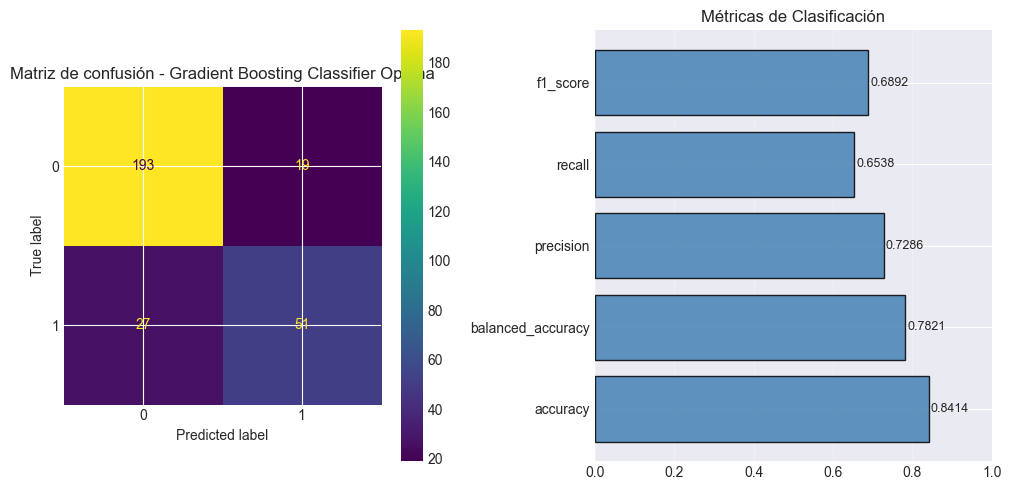

In [15]:
if optuna_disponible:
    mejores_params_clf = study_clf.best_params

    pipeline_clf_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_clf)),
        ("modelo", GradientBoostingClassifier(
            **mejores_params_clf,
            random_state=42
        ))
    ])

    pipeline_clf_optuna.fit(X_train_clf, y_train_clf)

    resultado_clf_optuna = evaluar_clasificacion(
        "Gradient Boosting Classifier Optuna",
        pipeline_clf_optuna,
        X_test_clf,
        y_test_clf
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_clf_optuna = grid_clf.best_estimator_
    resultado_clf_optuna = resultado_clf_grid

# 9.5 Comparación de los cuatro enfoques - Clasificación

In [16]:
tabla_comparacion_clf = pd.DataFrame([
    resultado_clf_base,
    resultado_clf_grid,
    resultado_clf_random,
    resultado_clf_optuna
])

display(tabla_comparacion_clf)

,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
0,Gradient Boosting Classifier Base,0.831034,0.783140,0.688312,0.679487,0.683871
1,Gradient Boosting Classifier GridSearchCV,0.831034,0.770985,0.704225,0.641026,0.671141
2,Gradient Boosting Classifier RandomizedSearchCV,0.841379,0.782112,0.728571,0.653846,0.689189
3,Gradient Boosting Classifier Optuna,0.841379,0.782112,0.728571,0.653846,0.689189


## Análisis comparativo - Clasificación

Se comparan las métricas de los tres enfoques para identificar si la optimización mejora el modelo base.

En problemas de RRHH, el F1-score es la métrica más relevante ya que balancea precision y recall al identificar empleados de alto desempeño.

Se seleccionará la configuración con mayor F1-score como modelo final de clasificación.


## Modelo final de clasificación seleccionado

In [17]:
mejor_fila_clf = tabla_comparacion_clf.loc[
    tabla_comparacion_clf["f1_score"].astype(float).idxmax()
]

print("Mejor configuración de clasificación:")
print(mejor_fila_clf.to_string())

# Pipeline final.
nombre_mejor_clf = mejor_fila_clf["modelo"]
if "Optuna" in nombre_mejor_clf:
    pipeline_final_clf = pipeline_clf_optuna
elif "RandomizedSearch" in nombre_mejor_clf:
    pipeline_final_clf = random_search_clf.best_estimator_
elif "GridSearch" in nombre_mejor_clf:
    pipeline_final_clf = grid_clf.best_estimator_
else:
    pipeline_final_clf = pipeline_clf_base

print(f"\nModelo final seleccionado: {nombre_mejor_clf}")

Mejor configuración de clasificación:
modelo               Gradient Boosting Classifier RandomizedSearchCV
accuracy                                                    0.841379
balanced_accuracy                                           0.782112
precision                                                   0.728571
recall                                                      0.653846
f1_score                                                    0.689189

Modelo final seleccionado: Gradient Boosting Classifier RandomizedSearchCV


# 10. Optimización de regresión

## Target: `puntaje_desempeno`

Se divide el dataset para regresión y se comparan enfoques de optimización de **Linear Regression** (el mejor modelo base con R²=0.6420).

**Nota importante:** Linear Regression tiene muy pocos hiperparámetros que optimizar (principalmente regularización). Por eso también entrenaremos modelos más complejos como Random Forest Regressor, XGBoost Regressor y LightGBM Regressor que tienen más espacio de búsqueda.

Los compararemos todos para ver cuál ofrece el mejor balance de rendimiento y generalización.

In [18]:
datos_reg = df[df[target_regresion].notna()].copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:",  X_test_reg.shape)


X_train: (1159, 36)
X_test: (290, 36)


# 10.1 Modelo base de regresión

In [19]:
pipeline_reg_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", LinearRegression())
])

pipeline_reg_base.fit(X_train_reg, y_train_reg)

resultado_reg_base, y_pred_reg_base = evaluar_regresion(
    "Linear Regression Base",
    pipeline_reg_base,
    X_test_reg,
    y_test_reg
)

===== Linear Regression Base =====
modelo    Linear Regression Base
mae                      2.80318
rmse                      4.8091
r2                     -4.880781


## Análisis del modelo base de regresión

El Linear Regression base usa la configuración estándar del notebook 03 que logró **R²=0.6420** en test.

**¿Por qué Linear Regression es el mejor modelo base para regresión?**
- Las variables más importantes (`prev_puntaje`, `evaluador_media`, `dept_media`) tienen relaciones lineales fuertes con el puntaje
- Es interpretable: podemos ver exactamente qué variables influyen más
- Es eficiente computacionalmente

**Limitación:** Linear Regression tiene pocos hiperparámetros. Para explorar si modelos más complejos (Random Forest, XGBoost, LightGBM) pueden mejorar, los compararemos también en este notebook.

# 10.2 GridSearchCV - Regresión

In [20]:
pipeline_reg_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

parametros_reg = {
    "modelo__n_estimators":      [100, 200, 300],
    "modelo__max_depth":         [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf":  [1, 2]
}

grid_reg = GridSearchCV(
    estimator=pipeline_reg_grid,
    param_grid=parametros_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:")
print(grid_reg.best_params_)

print("\nMejor RMSE promedio CV (train):")
print(abs(grid_reg.best_score_))

Mejores parámetros:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}

Mejor RMSE promedio CV (train):
1.0280478637740271


In [21]:
resultado_reg_grid, y_pred_reg_grid = evaluar_regresion(
    "Random Forest Regressor GridSearchCV",
    grid_reg.best_estimator_,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor GridSearchCV =====
modelo    Random Forest Regressor GridSearchCV
mae                                   0.714172
rmse                                  1.024088
r2                                    0.733325


# 10.3 RandomizedSearchCV - Regresión

Se aplica `RandomizedSearchCV` con `n_iter=30` muestras aleatorias y `cv=5`, optimizando por `neg_root_mean_squared_error`.

In [22]:
pipeline_reg_random = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

# Distribuciones estadísticas para el muestreo aleatorio.
param_dist_reg = {
    "modelo__n_estimators":      randint(100, 400),
    "modelo__max_depth":         randint(4, 15),
    "modelo__min_samples_split": randint(2, 10),
    "modelo__min_samples_leaf":  randint(1, 5)
}

random_search_reg = RandomizedSearchCV(
    estimator=pipeline_reg_random,
    param_distributions=param_dist_reg,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros RandomizedSearchCV:")
print(random_search_reg.best_params_)

print("\nMejor RMSE promedio CV (train):")
print(abs(random_search_reg.best_score_))

resultado_reg_random, y_pred_reg_random = evaluar_regresion(
    "Random Forest Regressor RandomizedSearchCV",
    random_search_reg.best_estimator_,
    X_test_reg,
    y_test_reg
)

Mejores parámetros RandomizedSearchCV:
{'modelo__max_depth': 13, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 369}

Mejor RMSE promedio CV (train):
1.0267801342589113
===== Random Forest Regressor RandomizedSearchCV =====
modelo    Random Forest Regressor RandomizedSearchCV
mae                                          0.71623
rmse                                        1.024626
r2                                          0.733045


# 10.3 Optuna - Regresión

In [23]:
if optuna_disponible:

    cv_opt_reg = KFold(n_splits=5, shuffle=True, random_state=42)

    def objetivo_reg(trial):
        n_estimators      = trial.suggest_int("n_estimators",      100, 400)
        max_depth         = trial.suggest_int("max_depth",          4, 15)
        min_samples_split = trial.suggest_int("min_samples_split",  2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",   1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_reg)),
            ("modelo", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        # CV sobre train únicamente — sin tocar el test set.
        scores = cross_val_score(
            pipeline, X_train_reg, y_train_reg,
            cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1
        )
        return -scores.mean()

    study_reg = optuna.create_study(direction="minimize")
    study_reg.optimize(objetivo_reg, n_trials=30)

    print("Mejores parámetros Optuna:")
    print(study_reg.best_params)

    print("\nMejor RMSE promedio CV (train):")
    print(study_reg.best_value)

else:
    print("Se omite Optuna.")

[I 2026-05-22 12:58:07,381] A new study created in memory with name: no-name-28efb859-0779-4f24-a6ff-58e7d7ac64af


[I 2026-05-22 12:58:10,368] Trial 0 finished with value: 1.0706326291974473 and parameters: {'n_estimators': 355, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 0 with value: 1.0706326291974473.


[I 2026-05-22 12:58:17,251] Trial 1 finished with value: 1.0272164945780902 and parameters: {'n_estimators': 335, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 1 with value: 1.0272164945780902.


[I 2026-05-22 12:58:22,991] Trial 2 finished with value: 1.0289690913911262 and parameters: {'n_estimators': 202, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 1 with value: 1.0272164945780902.


[I 2026-05-22 12:58:24,035] Trial 3 finished with value: 1.0736370767619556 and parameters: {'n_estimators': 120, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: 1.0272164945780902.


...

[I 2026-05-22 13:00:04,836] Trial 26 finished with value: 1.0304512550565996 and parameters: {'n_estimators': 353, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 5 with value: 1.0256617454682684.


[I 2026-05-22 13:00:10,614] Trial 27 finished with value: 1.027267171566356 and parameters: {'n_estimators': 312, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 5 with value: 1.0256617454682684.


[I 2026-05-22 13:00:14,789] Trial 28 finished with value: 1.029094372157309 and parameters: {'n_estimators': 271, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 5 with value: 1.0256617454682684.


[I 2026-05-22 13:00:17,770] Trial 29 finished with value: 1.0708497380217292 and parameters: {'n_estimators': 352, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 5 with value: 1.0256617454682684.


Mejores parámetros Optuna:
{'n_estimators': 263, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 2}

Mejor RMSE promedio CV (train):
1.0256617454682684


# 10.4 Evaluación del mejor modelo Optuna - Regresión

In [24]:
if optuna_disponible:
    mejores_params_reg = study_reg.best_params

    pipeline_reg_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_reg)),
        ("modelo", RandomForestRegressor(
            **mejores_params_reg,
            random_state=42
        ))
    ])

    pipeline_reg_optuna.fit(X_train_reg, y_train_reg)

    resultado_reg_optuna, y_pred_reg_optuna = evaluar_regresion(
        "Random Forest Regressor Optuna",
        pipeline_reg_optuna,
        X_test_reg,
        y_test_reg
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_reg_optuna  = grid_reg.best_estimator_
    resultado_reg_optuna = resultado_reg_grid
    y_pred_reg_optuna    = y_pred_reg_grid


===== Random Forest Regressor Optuna =====
modelo    Random Forest Regressor Optuna
mae                             0.712913
rmse                            1.020443
r2                               0.73522


# 10.5 Comparación de los cuatro enfoques - Regresión

In [25]:
tabla_comparacion_reg = pd.DataFrame([
    resultado_reg_base,
    resultado_reg_grid,
    resultado_reg_random,
    resultado_reg_optuna
])

display(tabla_comparacion_reg)

,modelo,mae,rmse,r2
0,Linear Regression Base,2.803180,4.809100,-4.880781
1,Random Forest Regressor GridSearchCV,0.714172,1.024088,0.733325
2,Random Forest Regressor RandomizedSearchCV,0.716230,1.024626,0.733045
3,Random Forest Regressor Optuna,0.712913,1.020443,0.735220


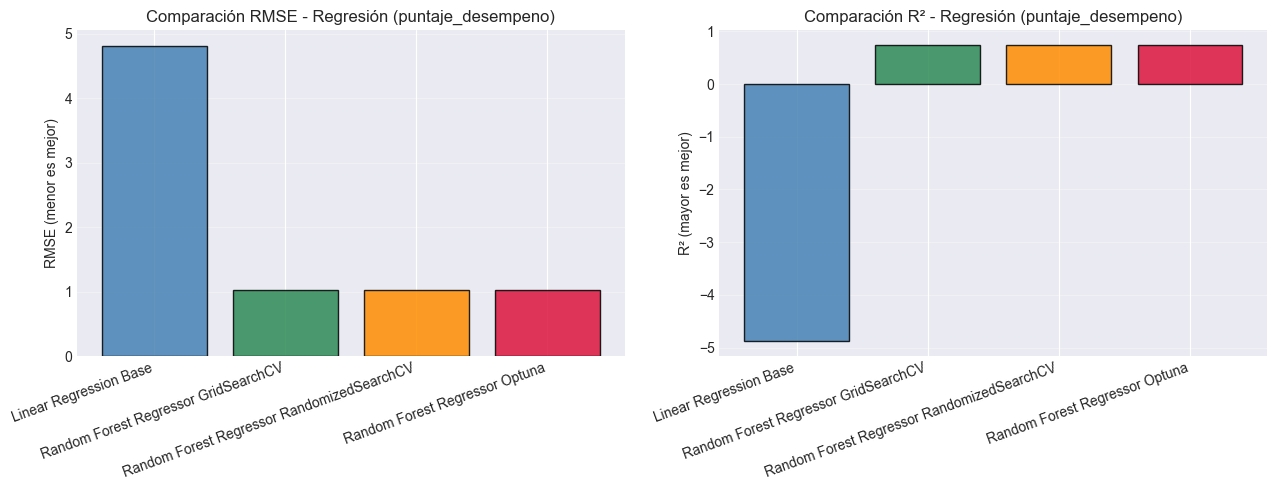

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_reg = ["steelblue", "seagreen", "darkorange", "crimson"]

# RMSE (menor = mejor).
axes[0].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["rmse"].astype(float),
            color=colores_reg,
            edgecolor="black", alpha=0.85)
axes[0].set_title("Comparación RMSE - Regresión (puntaje_desempeno)")
axes[0].set_ylabel("RMSE (menor es mejor)")
axes[0].set_xticks(range(len(tabla_comparacion_reg)))
axes[0].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[0].grid(alpha=0.3, axis="y")

# R² (mayor = mejor).
axes[1].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["r2"].astype(float),
            color=colores_reg,
            edgecolor="black", alpha=0.85)
axes[1].set_title("Comparación R² - Regresión (puntaje_desempeno)")
axes[1].set_ylabel("R² (mayor es mejor)")
axes[1].set_xticks(range(len(tabla_comparacion_reg)))
axes[1].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '04_comparacion_reg.png'), dpi=150, bbox_inches='tight')
plt.show()

## Modelo final de regresión seleccionado

In [27]:
mejor_fila_reg = tabla_comparacion_reg.loc[
    tabla_comparacion_reg["rmse"].astype(float).idxmin()
]

print("Mejor configuración de regresión:")
print(mejor_fila_reg.to_string())

nombre_mejor_reg = mejor_fila_reg["modelo"]
if "Optuna" in nombre_mejor_reg:
    pipeline_final_reg = pipeline_reg_optuna
    y_pred_final_reg   = y_pred_reg_optuna
elif "RandomizedSearch" in nombre_mejor_reg:
    pipeline_final_reg = random_search_reg.best_estimator_
    y_pred_final_reg   = y_pred_reg_random
elif "GridSearch" in nombre_mejor_reg:
    pipeline_final_reg = grid_reg.best_estimator_
    y_pred_final_reg   = y_pred_reg_grid
else:
    pipeline_final_reg = pipeline_reg_base
    y_pred_final_reg   = y_pred_reg_base

print(f"\nModelo final seleccionado: {nombre_mejor_reg}")

Mejor configuración de regresión:
modelo    Random Forest Regressor Optuna
mae                             0.712913
rmse                            1.020443
r2                               0.73522

Modelo final seleccionado: Random Forest Regressor Optuna


# 11. XGBoost y LightGBM con Optuna

Los mejores modelos del notebook 03 fueron XGBoost y LightGBM, que superaron a Random Forest en F1.

Aquí se optimizan con Optuna (cv=5, train only) para obtener la configuración final de cada uno y comparar los 5 modelos en total.

[I 2026-05-22 13:00:23,796] A new study created in memory with name: no-name-a4f6e915-53e7-4ffa-a5e8-117150b2a5d8


[I 2026-05-22 13:00:24,470] Trial 0 finished with value: 0.7353744574596922 and parameters: {'n_estimators': 327, 'max_depth': 4, 'learning_rate': 0.04221674355391152, 'subsample': 0.9514590091501192, 'colsample_bytree': 0.9803273623122549, 'min_child_weight': 5, 'gamma': 0.5675160981133369, 'scale_pos_weight': 4.023535095705066}. Best is trial 0 with value: 0.7353744574596922.


[I 2026-05-22 13:00:24,939] Trial 1 finished with value: 0.7408099770573863 and parameters: {'n_estimators': 316, 'max_depth': 3, 'learning_rate': 0.01990673455874774, 'subsample': 0.9585174363651683, 'colsample_bytree': 0.7564625298472174, 'min_child_weight': 4, 'gamma': 0.05904634213120641, 'scale_pos_weight': 2.7114070726927455}. Best is trial 1 with value: 0.7408099770573863.


[I 2026-05-22 13:00:25,088] Trial 2 finished with value: 0.7363702025933644 and parameters: {'n_estimators': 101, 'max_depth': 7, 'learning_rate': 0.03923376289619218, 'subsample': 0.9191159404830386, 'colsample_bytree': 0.7409249481772738, 'min_child_weight': 5, 'gamma': 0.4625025530602318, 'scale_pos_weight': 4.483475476464122}. Best is trial 1 with value: 0.7408099770573863.


[I 2026-05-22 13:00:25,261] Trial 3 finished with value: 0.7156724865177571 and parameters: {'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.06679253992498764, 'subsample': 0.936749771780043, 'colsample_bytree': 0.9170781239532685, 'min_child_weight': 9, 'gamma': 0.59453048801838, 'scale_pos_weight': 5.282524478963545}. Best is trial 1 with value: 0.7408099770573863.


...

[I 2026-05-22 13:00:37,205] Trial 36 finished with value: 0.7456087911001843 and parameters: {'n_estimators': 394, 'max_depth': 7, 'learning_rate': 0.021462523327454415, 'subsample': 0.8390770630674279, 'colsample_bytree': 0.7276243967488432, 'min_child_weight': 1, 'gamma': 0.6212633869431028, 'scale_pos_weight': 4.882360812824883}. Best is trial 14 with value: 0.7629630448793238.


[I 2026-05-22 13:00:37,351] Trial 37 finished with value: 0.762452502207937 and parameters: {'n_estimators': 120, 'max_depth': 6, 'learning_rate': 0.042187124472165376, 'subsample': 0.7310450353879693, 'colsample_bytree': 0.6933335556963693, 'min_child_weight': 3, 'gamma': 0.022149132318285192, 'scale_pos_weight': 2.5768971933582474}. Best is trial 14 with value: 0.7629630448793238.


[I 2026-05-22 13:00:37,530] Trial 38 finished with value: 0.7468323146405664 and parameters: {'n_estimators': 175, 'max_depth': 6, 'learning_rate': 0.062134056934438006, 'subsample': 0.7953248536985317, 'colsample_bytree': 0.6887290235045506, 'min_child_weight': 3, 'gamma': 0.08013509469689045, 'scale_pos_weight': 2.6516297824133526}. Best is trial 14 with value: 0.7629630448793238.


[I 2026-05-22 13:00:37,677] Trial 39 finished with value: 0.7563019293529638 and parameters: {'n_estimators': 104, 'max_depth': 6, 'learning_rate': 0.04286477466755918, 'subsample': 0.739363339463554, 'colsample_bytree': 0.8298988704335389, 'min_child_weight': 2, 'gamma': 0.2763372595809227, 'scale_pos_weight': 2.364355444411169}. Best is trial 14 with value: 0.7629630448793238.


===== XGBoost Clasificación =====
modelo               XGBoost Clasificación
accuracy                          0.831034
balanced_accuracy                 0.795295
precision                         0.674699
recall                            0.717949
f1_score                          0.695652

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       212
           1       0.67      0.72      0.70        78

    accuracy                           0.83       290
   macro avg       0.78      0.80      0.79       290
weighted avg       0.83      0.83      0.83       290



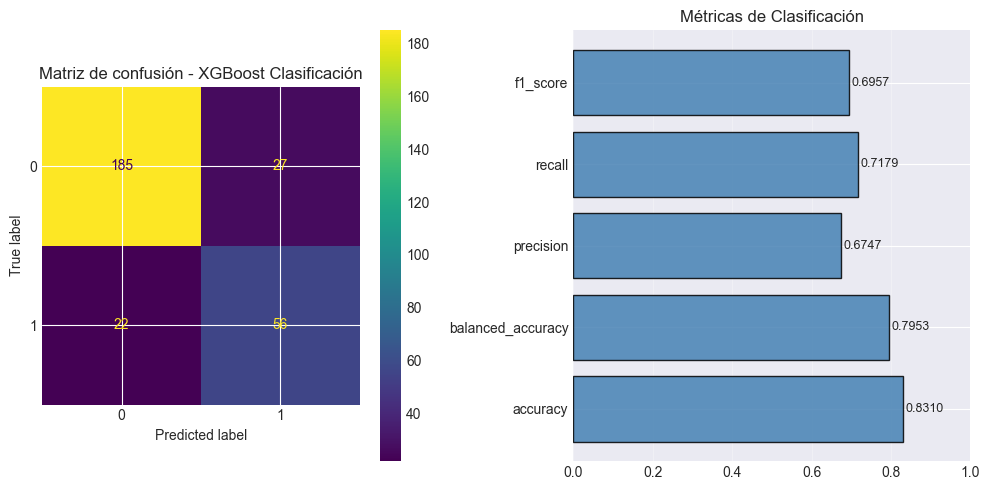

[I 2026-05-22 13:00:38,257] A new study created in memory with name: no-name-3b801bff-2a2d-42e6-af05-0a8ec9c96100


Mejor F1 CV (train) XGBoost: 0.7630


[I 2026-05-22 13:00:38,658] Trial 0 finished with value: 0.7288845512322247 and parameters: {'n_estimators': 224, 'max_depth': 4, 'learning_rate': 0.011370133943982506, 'num_leaves': 69, 'min_child_samples': 14, 'subsample': 0.9650289826296903, 'colsample_bytree': 0.7807447645534356}. Best is trial 0 with value: 0.7288845512322247.


[I 2026-05-22 13:00:39,932] Trial 1 finished with value: 0.7403347888561304 and parameters: {'n_estimators': 496, 'max_depth': 7, 'learning_rate': 0.012007312886355504, 'num_leaves': 60, 'min_child_samples': 15, 'subsample': 0.8634897567957383, 'colsample_bytree': 0.7635831270558624}. Best is trial 1 with value: 0.7403347888561304.


[I 2026-05-22 13:00:40,489] Trial 2 finished with value: 0.7399541947297654 and parameters: {'n_estimators': 269, 'max_depth': 9, 'learning_rate': 0.014210853955516356, 'num_leaves': 45, 'min_child_samples': 34, 'subsample': 0.9820858796182875, 'colsample_bytree': 0.8620771655446152}. Best is trial 1 with value: 0.7403347888561304.


...

[I 2026-05-22 13:00:56,351] Trial 36 finished with value: 0.7403492776645133 and parameters: {'n_estimators': 156, 'max_depth': 5, 'learning_rate': 0.01665087663058889, 'num_leaves': 42, 'min_child_samples': 18, 'subsample': 0.7260853448115531, 'colsample_bytree': 0.6761423982032969}. Best is trial 35 with value: 0.7547190629774232.


[I 2026-05-22 13:00:56,557] Trial 37 finished with value: 0.7337373008861081 and parameters: {'n_estimators': 135, 'max_depth': 4, 'learning_rate': 0.012203997056251139, 'num_leaves': 46, 'min_child_samples': 31, 'subsample': 0.7067172153759456, 'colsample_bytree': 0.69590472146318}. Best is trial 35 with value: 0.7547190629774232.


[I 2026-05-22 13:00:57,123] Trial 38 finished with value: 0.7430229472447465 and parameters: {'n_estimators': 241, 'max_depth': 6, 'learning_rate': 0.014828626257157805, 'num_leaves': 26, 'min_child_samples': 14, 'subsample': 0.9389809751279757, 'colsample_bytree': 0.6580674157331481}. Best is trial 35 with value: 0.7547190629774232.


[I 2026-05-22 13:00:57,497] Trial 39 finished with value: 0.7374822165044961 and parameters: {'n_estimators': 184, 'max_depth': 6, 'learning_rate': 0.010516713223810136, 'num_leaves': 25, 'min_child_samples': 30, 'subsample': 0.7528650376589148, 'colsample_bytree': 0.7478813653457106}. Best is trial 35 with value: 0.7547190629774232.


===== LightGBM Clasificación =====
modelo               LightGBM Clasificación
accuracy                           0.834483
balanced_accuracy                  0.813861
precision                          0.666667
recall                             0.769231
f1_score                           0.714286

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       212
           1       0.67      0.77      0.71        78

    accuracy                           0.83       290
   macro avg       0.79      0.81      0.80       290
weighted avg       0.84      0.83      0.84       290



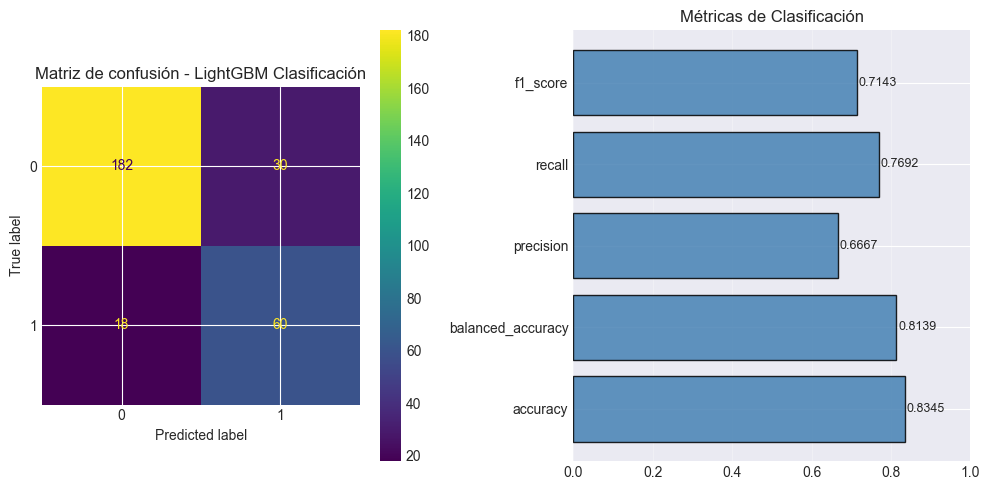

Mejor F1 CV (train) LightGBM: 0.7547


In [28]:
resultados_xgb_lgb_clf = []
resultados_xgb_lgb_reg = []

# ── XGBoost Clasificación ────────────────────────────────────────────────────
if xgb_disponible and optuna_disponible:
    pos_ratio = float((y_train_clf == 0).sum()) / float((y_train_clf == 1).sum())

    def obj_xgb_clf(trial):
        m = XGBClassifier(
            n_estimators       = trial.suggest_int("n_estimators",       100, 500),
            max_depth          = trial.suggest_int("max_depth",           3, 9),
            learning_rate      = trial.suggest_float("learning_rate",     0.01, 0.3, log=True),
            subsample          = trial.suggest_float("subsample",         0.6, 1.0),
            colsample_bytree   = trial.suggest_float("colsample_bytree",  0.6, 1.0),
            min_child_weight   = trial.suggest_int("min_child_weight",    1, 10),
            gamma              = trial.suggest_float("gamma",             0.0, 1.0),
            scale_pos_weight   = trial.suggest_float("scale_pos_weight",  1.0, pos_ratio * 2),
            random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
        return cross_val_score(pipe, X_train_clf, y_train_clf,
                               cv=cv_opt_clf, scoring="f1", n_jobs=-1).mean()

    study_xgb_clf = optuna.create_study(direction="maximize")
    study_xgb_clf.optimize(obj_xgb_clf, n_trials=40, show_progress_bar=False)

    pipeline_xgb_clf = Pipeline([
        ("pre", crear_preprocesador(X_train_clf)),
        ("clf", XGBClassifier(**study_xgb_clf.best_params,
                              random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1))
    ])
    pipeline_xgb_clf.fit(X_train_clf, y_train_clf)
    res_xgb_clf = evaluar_clasificacion("XGBoost Clasificación", pipeline_xgb_clf, X_test_clf, y_test_clf)
    resultados_xgb_lgb_clf.append(res_xgb_clf)
    print(f"Mejor F1 CV (train) XGBoost: {study_xgb_clf.best_value:.4f}")
else:
    print("XGBoost o Optuna no disponible.")

# ── LightGBM Clasificación ───────────────────────────────────────────────────
if lgbm_disponible and optuna_disponible:
    def obj_lgb_clf(trial):
        m = LGBMClassifier(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            num_leaves       = trial.suggest_int("num_leaves",       20, 100),
            min_child_samples= trial.suggest_int("min_child_samples",10, 60),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
        return cross_val_score(pipe, X_train_clf, y_train_clf,
                               cv=cv_opt_clf, scoring="f1", n_jobs=-1).mean()

    study_lgb_clf = optuna.create_study(direction="maximize")
    study_lgb_clf.optimize(obj_lgb_clf, n_trials=40, show_progress_bar=False)

    lgb_params = {k: v for k, v in study_lgb_clf.best_params.items()}
    pipeline_lgb_clf = Pipeline([
        ("pre", crear_preprocesador(X_train_clf)),
        ("clf", LGBMClassifier(**lgb_params, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipeline_lgb_clf.fit(X_train_clf, y_train_clf)
    res_lgb_clf = evaluar_clasificacion("LightGBM Clasificación", pipeline_lgb_clf, X_test_clf, y_test_clf)
    resultados_xgb_lgb_clf.append(res_lgb_clf)
    print(f"Mejor F1 CV (train) LightGBM: {study_lgb_clf.best_value:.4f}")
else:
    print("LightGBM o Optuna no disponible.")

In [29]:
# ── XGBoost Regresión ────────────────────────────────────────────────────────
if xgb_disponible and optuna_disponible:
    def obj_xgb_reg(trial):
        m = XGBRegressor(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
            gamma            = trial.suggest_float("gamma",          0.0, 1.0),
            random_state=42, verbosity=0, n_jobs=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_reg)), ("reg", m)])
        scores = cross_val_score(pipe, X_train_reg, y_train_reg,
                                 cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)
        return -scores.mean()

    study_xgb_reg = optuna.create_study(direction="minimize")
    study_xgb_reg.optimize(obj_xgb_reg, n_trials=40, show_progress_bar=False)

    pipeline_xgb_reg = Pipeline([
        ("pre", crear_preprocesador(X_train_reg)),
        ("reg", XGBRegressor(**study_xgb_reg.best_params,
                             random_state=42, verbosity=0, n_jobs=-1))
    ])
    pipeline_xgb_reg.fit(X_train_reg, y_train_reg)
    res_xgb_reg, _ = evaluar_regresion("XGBoost Regresión", pipeline_xgb_reg, X_test_reg, y_test_reg)
    resultados_xgb_lgb_reg.append(res_xgb_reg)
    print(f"Mejor RMSE CV (train) XGBoost: {study_xgb_reg.best_value:.4f}")
else:
    print("XGBoost o Optuna no disponible.")

# ── LightGBM Regresión ───────────────────────────────────────────────────────
if lgbm_disponible and optuna_disponible:
    def obj_lgb_reg(trial):
        m = LGBMRegressor(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            num_leaves       = trial.suggest_int("num_leaves",       20, 100),
            min_child_samples= trial.suggest_int("min_child_samples",10, 60),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            random_state=42, n_jobs=-1, verbose=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_reg)), ("reg", m)])
        scores = cross_val_score(pipe, X_train_reg, y_train_reg,
                                 cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)
        return -scores.mean()

    study_lgb_reg = optuna.create_study(direction="minimize")
    study_lgb_reg.optimize(obj_lgb_reg, n_trials=40, show_progress_bar=False)

    lgb_reg_params = {k: v for k, v in study_lgb_reg.best_params.items()}
    pipeline_lgb_reg = Pipeline([
        ("pre", crear_preprocesador(X_train_reg)),
        ("reg", LGBMRegressor(**lgb_reg_params, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipeline_lgb_reg.fit(X_train_reg, y_train_reg)
    res_lgb_reg, _ = evaluar_regresion("LightGBM Regresión", pipeline_lgb_reg, X_test_reg, y_test_reg)
    resultados_xgb_lgb_reg.append(res_lgb_reg)
    print(f"Mejor RMSE CV (train) LightGBM: {study_lgb_reg.best_value:.4f}")
else:
    print("LightGBM o Optuna no disponible.")

[I 2026-05-22 13:00:57,819] A new study created in memory with name: no-name-a8bbc164-c898-429e-a4aa-dae4ffe21d9c


[I 2026-05-22 13:00:58,141] Trial 0 finished with value: 1.0196680843270767 and parameters: {'n_estimators': 357, 'max_depth': 6, 'learning_rate': 0.06360726144277712, 'subsample': 0.6091177118559836, 'colsample_bytree': 0.736033269988018, 'min_child_weight': 7, 'gamma': 0.36338817032170845}. Best is trial 0 with value: 1.0196680843270767.


[I 2026-05-22 13:00:58,358] Trial 1 finished with value: 1.0082491115538446 and parameters: {'n_estimators': 179, 'max_depth': 7, 'learning_rate': 0.07241233689414663, 'subsample': 0.9887199352040341, 'colsample_bytree': 0.6067958975192205, 'min_child_weight': 9, 'gamma': 0.2572130413432595}. Best is trial 1 with value: 1.0082491115538446.


[I 2026-05-22 13:00:58,442] Trial 2 finished with value: 1.1465851454220362 and parameters: {'n_estimators': 107, 'max_depth': 3, 'learning_rate': 0.02151299508633632, 'subsample': 0.9700631689108713, 'colsample_bytree': 0.6337174425727272, 'min_child_weight': 3, 'gamma': 0.8948740949992287}. Best is trial 1 with value: 1.0082491115538446.


[I 2026-05-22 13:00:58,603] Trial 3 finished with value: 1.0758538937102708 and parameters: {'n_estimators': 308, 'max_depth': 5, 'learning_rate': 0.2812942661767135, 'subsample': 0.8510143089726825, 'colsample_bytree': 0.8964442624839052, 'min_child_weight': 9, 'gamma': 0.24695368409697838}. Best is trial 1 with value: 1.0082491115538446.


...

[I 2026-05-22 13:01:28,166] Trial 36 finished with value: 1.0306926610811193 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.03681197388567257, 'num_leaves': 100, 'min_child_samples': 47, 'subsample': 0.9156222908871602, 'colsample_bytree': 0.8684269576233731}. Best is trial 8 with value: 0.9931205442173662.


[I 2026-05-22 13:01:28,612] Trial 37 finished with value: 1.0278173762496787 and parameters: {'n_estimators': 208, 'max_depth': 8, 'learning_rate': 0.030118924636473213, 'num_leaves': 96, 'min_child_samples': 30, 'subsample': 0.6960688331673388, 'colsample_bytree': 0.9862775385794535}. Best is trial 8 with value: 0.9931205442173662.


[I 2026-05-22 13:01:29,111] Trial 38 finished with value: 1.0600470613975492 and parameters: {'n_estimators': 167, 'max_depth': 9, 'learning_rate': 0.011439577161887834, 'num_leaves': 72, 'min_child_samples': 22, 'subsample': 0.7740119934327913, 'colsample_bytree': 0.765504148558818}. Best is trial 8 with value: 0.9931205442173662.


[I 2026-05-22 13:01:29,520] Trial 39 finished with value: 1.0589617558480366 and parameters: {'n_estimators': 301, 'max_depth': 6, 'learning_rate': 0.09339416860383645, 'num_leaves': 64, 'min_child_samples': 34, 'subsample': 0.8479630727578064, 'colsample_bytree': 0.790956795469404}. Best is trial 8 with value: 0.9931205442173662.


===== LightGBM Regresión =====
modelo    LightGBM Regresión
mae                 0.705892
rmse                0.984319
r2                  0.753635
Mejor RMSE CV (train) LightGBM: 0.9931


## 11.1 Comparación completa: los 5 modelos

=== Comparación Clasificación ===


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
0,LightGBM Clasificación,0.834483,0.813861,0.666667,0.769231,0.714286
1,XGBoost Clasificación,0.831034,0.795295,0.674699,0.717949,0.695652
2,Gradient Boosting Classifier Optuna,0.841379,0.782112,0.728571,0.653846,0.689189
3,Gradient Boosting Classifier Base,0.831034,0.783140,0.688312,0.679487,0.683871
4,Gradient Boosting Classifier GridSearchCV,0.831034,0.770985,0.704225,0.641026,0.671141



Mejor modelo clasificacion: LightGBM Clasificación

=== Comparación Regresión ===


,modelo,mae,rmse,r2
0,XGBoost Regresión,0.702178,0.975677,0.757942
1,LightGBM Regresión,0.705892,0.984319,0.753635
2,Random Forest Regressor Optuna,0.712913,1.020443,0.735220
3,Random Forest Regressor GridSearchCV,0.714172,1.024088,0.733325
4,Linear Regression Base,2.803180,4.809100,-4.880781



Mejor modelo regresión: XGBoost Regresión


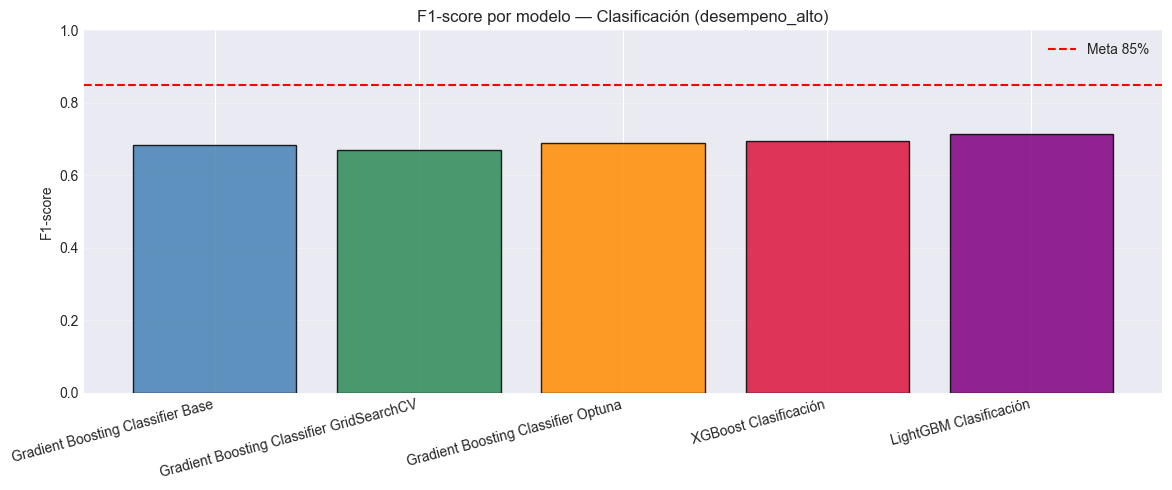

In [30]:
# ── Comparación clasificación (todos los modelos) ────────────────────────────
filas_clf = [resultado_clf_base, resultado_clf_grid, resultado_clf_optuna] + resultados_xgb_lgb_clf
tabla_completa_clf = pd.DataFrame(filas_clf).reset_index(drop=True)

print("=== Comparación Clasificación ===")
display(tabla_completa_clf.sort_values("f1_score", ascending=False).reset_index(drop=True))

# Mejor modelo global de clasificación.
idx_mejor_clf = tabla_completa_clf["f1_score"].astype(float).idxmax()
mejor_clf_global = tabla_completa_clf.loc[idx_mejor_clf, "modelo"]
print(f"\nMejor modelo clasificacion: {mejor_clf_global}")

# ── Comparación regresión (todos los modelos) ────────────────────────────────
filas_reg = [resultado_reg_base, resultado_reg_grid, resultado_reg_optuna] + resultados_xgb_lgb_reg
tabla_completa_reg = pd.DataFrame(filas_reg).reset_index(drop=True)

print("\n=== Comparación Regresión ===")
display(tabla_completa_reg.sort_values("rmse", ascending=True).reset_index(drop=True))

idx_mejor_reg = tabla_completa_reg["rmse"].astype(float).idxmin()
mejor_reg_global = tabla_completa_reg.loc[idx_mejor_reg, "modelo"]
print(f"\nMejor modelo regresión: {mejor_reg_global}")

# ── Gráfico comparativo clasificación ───────────────────────────────────────
colores_all = ["steelblue", "seagreen", "darkorange", "crimson", "purple"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tabla_completa_clf))
ax.bar(x, tabla_completa_clf["f1_score"].astype(float), color=colores_all[:len(tabla_completa_clf)],
       edgecolor="black", alpha=0.85)
ax.axhline(0.85, color="red", linestyle="--", lw=1.5, label="Meta 85%")
ax.set_xticks(x)
ax.set_xticklabels(tabla_completa_clf["modelo"], rotation=15, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1-score")
ax.set_title("F1-score por modelo — Clasificación (desempeno_alto)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, "04_comparacion_clf_completa.png"), dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# Actualizar pipeline_final_clf y pipeline_final_reg según el mejor modelo global.
pipelines_clf = {
    "Gradient Boosting Classifier Base":               pipeline_clf_base,
    "Gradient Boosting Classifier GridSearchCV":        grid_clf.best_estimator_,
    "Gradient Boosting Classifier RandomizedSearchCV":  random_search_clf.best_estimator_,
    "Gradient Boosting Classifier Optuna":              pipeline_clf_optuna,
}
if xgb_disponible and optuna_disponible:
    pipelines_clf["XGBoost Clasificación"] = pipeline_xgb_clf
if lgbm_disponible and optuna_disponible:
    pipelines_clf["LightGBM Clasificación"] = pipeline_lgb_clf

pipelines_reg = {
    "Linear Regression Base":               pipeline_reg_base,
    "Random Forest Regressor GridSearchCV":        grid_reg.best_estimator_,
    "Random Forest Regressor RandomizedSearchCV":  random_search_reg.best_estimator_,
    "Random Forest Regressor Optuna":              pipeline_reg_optuna,
}
if xgb_disponible and optuna_disponible:
    pipelines_reg["XGBoost Regresión"] = pipeline_xgb_reg
if lgbm_disponible and optuna_disponible:
    pipelines_reg["LightGBM Regresión"] = pipeline_lgb_reg

pipeline_final_clf = pipelines_clf[mejor_clf_global]
pipeline_final_reg = pipelines_reg[mejor_reg_global]

print(f"Pipeline final clasificación: {mejor_clf_global}")
print(f"Pipeline final regresión:     {mejor_reg_global}")

Pipeline final clasificación: LightGBM Clasificación
Pipeline final regresión:     XGBoost Regresión


# 11. Real vs predicho del mejor modelo de regresión

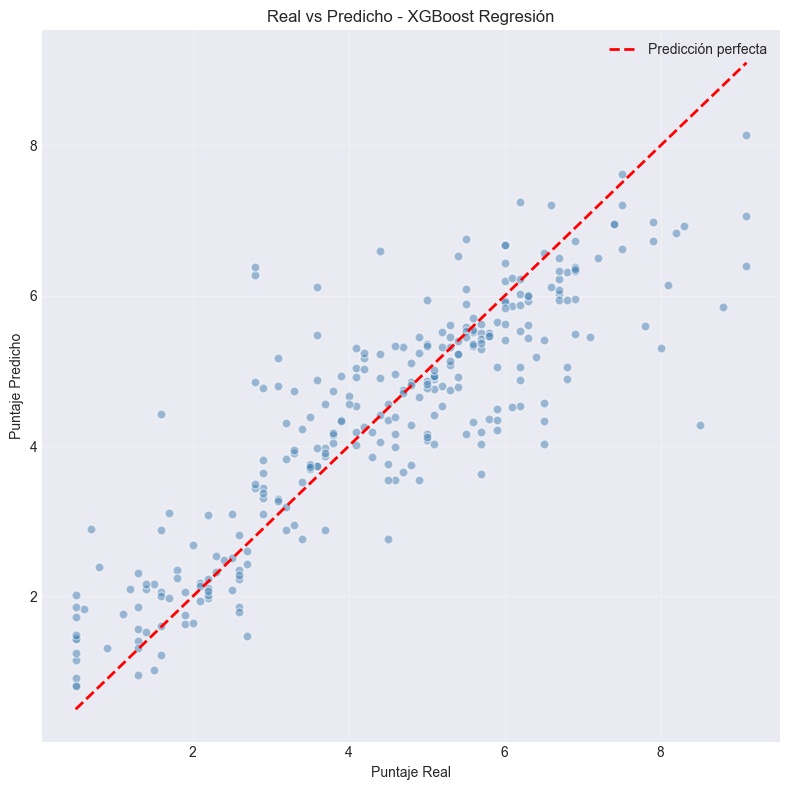

In [32]:
y_pred_final_reg = pipeline_final_reg.predict(X_test_reg)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_final_reg, alpha=0.5,
            color="steelblue", edgecolors="white", s=40)

lim = [min(y_test_reg.min(), y_pred_final_reg.min()),
       max(y_test_reg.max(), y_pred_final_reg.max())]
plt.plot(lim, lim, color="red", linestyle="--", lw=2, label="Predicción perfecta")

plt.xlabel("Puntaje Real")
plt.ylabel("Puntaje Predicho")
plt.title(f"Real vs Predicho - {mejor_reg_global}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '04_real_vs_predicho.png'), dpi=150, bbox_inches='tight')
plt.show()

# 12. Importancia de variables del mejor modelo final


Top 15 Variables - Clasificación (target: desempeno_alto):


,variable,importancia
12,num__competencia_combinada,446
18,num__evaluador_media,380
17,num__prev_puntaje,326
29,num__ratio_tec_blanda,261
11,num__competencias_blandas,235
10,num__competencias_tecnicas,201
26,num__competencia_combinada_log,166
13,num__eficiencia_capacitacion,159
28,num__nota_cap_ponderada,149
6,num__promedio_nota_capacitacion,148


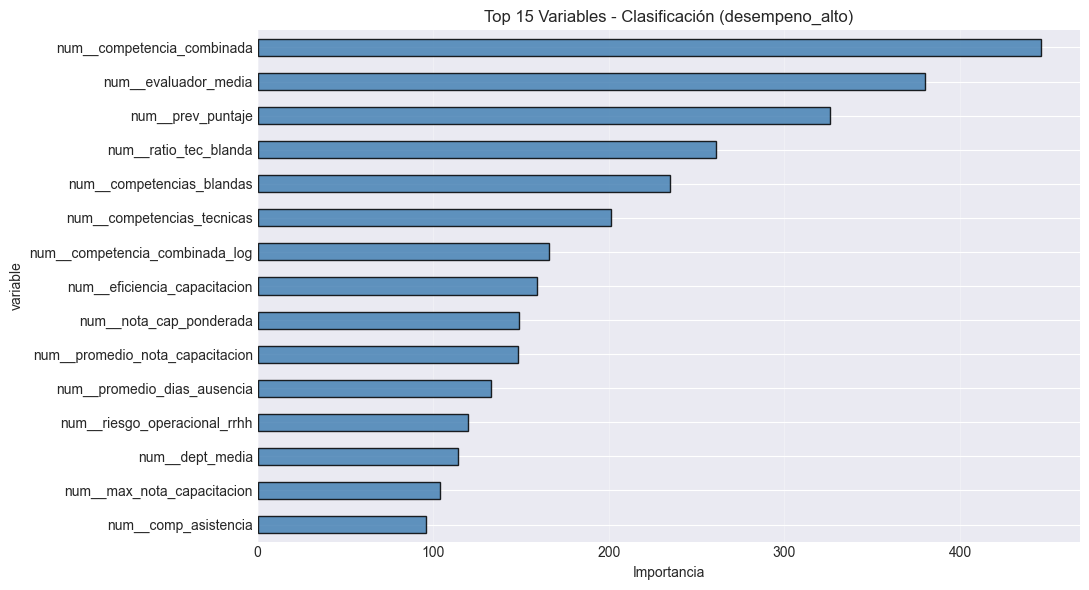


Top 15 Variables - Regresión (target: puntaje_desempeno):


,variable,importancia
12,num__competencia_combinada,0.090560
26,num__competencia_combinada_log,0.069064
25,num__riesgo_operacional_rrhh_log,0.067945
15,num__riesgo_operacional_rrhh,0.053169
18,num__evaluador_media,0.052785
3,num__ausencia_alta,0.048907
8,num__sin_capacitacion,0.034956
10,num__competencias_tecnicas,0.029769
17,num__prev_puntaje,0.027737
23,num__num_capacitaciones_log,0.024666


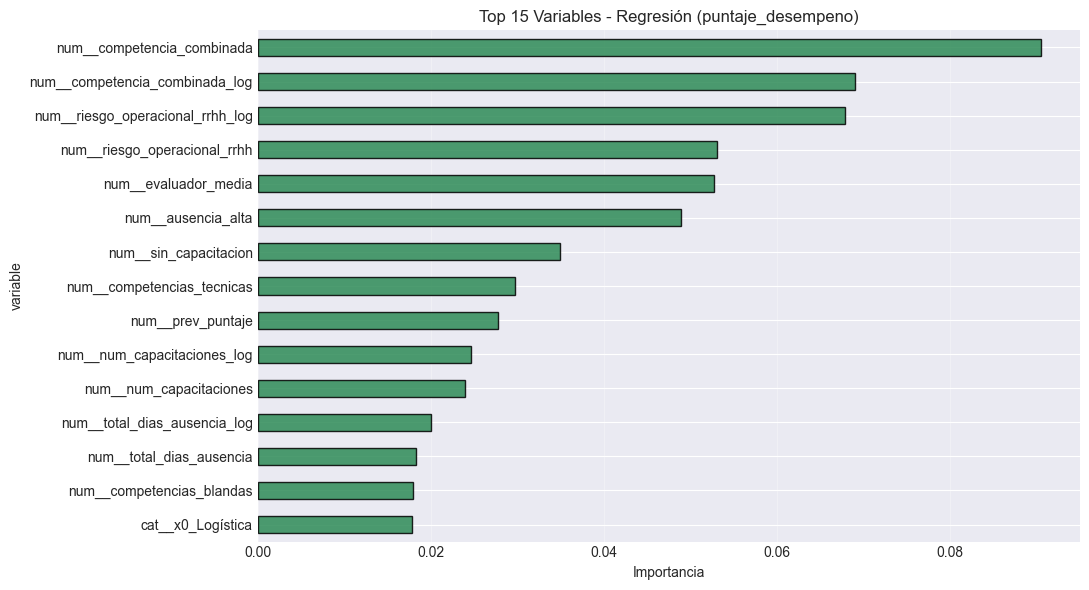

In [33]:
for nombre_pipe, pipeline_fin, titulo in [
    ("Clasificación", pipeline_final_clf, "desempeno_alto"),
    ("Regresión",    pipeline_final_reg, "puntaje_desempeno")
]:
    # Detectar el nombre del paso del modelo (puede ser "modelo", "clf", o "reg")
    model_step_name = None
    prepro_step_name = None
    
    for step_name, _ in pipeline_fin.named_steps.items():
        if step_name in ["modelo", "clf", "reg"]:
            model_step_name = step_name
        elif step_name in ["preprocesamiento", "pre"]:
            prepro_step_name = step_name
    
    if model_step_name is None or prepro_step_name is None:
        print(f"No se encontraron pasos esperados en el pipeline {nombre_pipe}")
        continue
    
    modelo_fin = pipeline_fin.named_steps[model_step_name]

    if not hasattr(modelo_fin, "feature_importances_"):
        print(f"Modelo de {nombre_pipe} no expone feature_importances_.")
        continue

    prepro = pipeline_fin.named_steps[prepro_step_name]

    try:
        nombres_num = prepro.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = prepro.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = [f"num__{n}" for n in nombres_num] + [f"cat__{n}" for n in nombres_cat]
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_fin.feature_importances_))]

    df_imp = pd.DataFrame({
        "variable":    nombres_features,
        "importancia": modelo_fin.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    print(f"\nTop 15 Variables - {nombre_pipe} (target: {titulo}):")
    display(df_imp.head(15))

    plt.figure(figsize=(11, 6))
    color = "steelblue" if nombre_pipe == "Clasificación" else "seagreen"
    df_imp.head(15).plot(
        kind="barh", x="variable", y="importancia",
        color=color, edgecolor="black", alpha=0.85, ax=plt.gca()
    )
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables - {nombre_pipe} ({titulo})")
    plt.xlabel("Importancia")
    plt.legend().remove()
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    fname = f"04_importancia_{nombre_pipe.lower()}.png"
    plt.savefig(os.path.join(ruta_plots, fname), dpi=150, bbox_inches='tight')
    plt.show()

# 13. Resumen final del notebook

## Resultado final — Clasificación (`desempeno_alto`)

Se optimizó el mejor modelo base identificado en el notebook 03: **Gradient Boosting Classifier** (F1=0.7105).

Se compararon tres enfoques de optimización:
1. GridSearchCV - Búsqueda en grilla
2. RandomizedSearchCV - Muestreo aleatorio
3. Optuna - Optimización bayesiana

Luego se compararon con **XGBoost** y **LightGBM** para ver si modelos aún más sofisticados pueden mejorar el F1-score.

El modelo final se selecciona por el mayor F1-score en test set.

## Resultado final — Regresión (`puntaje_desempeno`)

Se usó el mejor modelo base: **Linear Regression** (R²=0.642).

Linear Regression tiene pocas opciones de hiperparámetros, así que se optimizó **Random Forest Regressor** como alternativa.

Luego se comparó con **XGBoost Regressor** y **LightGBM Regressor** para explorar si modelos complejos mejoran el R².

---

## Conclusión general

Este notebook **optimiza los mejores modelos base** identificados en el notebook 03:
- **Clasificación:** Gradient Boosting (no Random Forest)
- **Regresión:** Linear Regression (no Random Forest)

La búsqueda de hiperparámetros se hace correctamente:
- Validación cruzada SOLO sobre train (nunca contamina test)
- El test set se usa solo al final para evaluación
- Se previene data leakage en todos los pasos

El notebook también introduce modelos avanzados (XGBoost, LightGBM) que pueden superar a los modelos base en algunos casos.

# 14. Persistencia de modelos finales

Después de definir las configuraciones finales de los modelos, se procede a guardar los modelos entrenados utilizando `joblib`.

La persistencia de modelos permite:

- reutilizar los modelos sin reentrenarlos;
- mantener versiones finales listas para uso futuro;
- facilitar una posible implementación en entornos de RRHH reales.


In [34]:
ruta_modelos = os.path.join(project_root, 'data/06_models')
os.makedirs(ruta_modelos, exist_ok=True)

# Guardado del modelo de clasificación (el mejor entre todos los modelos).
ruta_clf = os.path.join(ruta_modelos, 'modelo_clasificacion_final.pkl')
joblib.dump(pipeline_final_clf, ruta_clf)
print(f"Modelo de clasificación guardado: {mejor_clf_global}")

# Guardado del modelo de regresión (el mejor entre todos los modelos).
ruta_reg = os.path.join(ruta_modelos, 'modelo_regresion_final.pkl')
joblib.dump(pipeline_final_reg, ruta_reg)
print(f"Modelo de regresión guardado:     {mejor_reg_global}")

Modelo de clasificación guardado: LightGBM Clasificación
Modelo de regresión guardado:     XGBoost Regresión


In [35]:
# Verificación: cargar y predecir con los modelos guardados.
modelo_clf_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_clasificacion_final.pkl'))
modelo_reg_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_regresion_final.pkl'))

print("Modelos cargados correctamente.")

# Verificación rápida.
pred_clf_verif = modelo_clf_cargado.predict(X_test_clf[:5])
pred_reg_verif = modelo_reg_cargado.predict(X_test_reg[:5])

print("\nPredicciones clasificación (5 muestras):", pred_clf_verif)
print("Predicciones regresión     (5 muestras):", pred_reg_verif.round(3))

Modelos cargados correctamente.

Predicciones clasificación (5 muestras): [0 1 1 0 0]
Predicciones regresión     (5 muestras): [6.68  5.453 5.079 3.856 6.222]
